# Laboratorio 7 — Evaluación y Comparación de Modelos
## Dataset: Alquiler de Bicicletas en Seúl
**Curso:** Minería de Datos (EIN132A25)
**Objetivo:** Predecir demanda alta/baja de alquiler de bicicletas

## Objetivos
- Analizar patrones en datos de series temporales
- Entender correlaciones entre variables climáticas y demanda
- Evaluar y comparar múltiples algoritmos
- Interpretar decisiones del modelo (árbol de decisión)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, cross_validate
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    confusion_matrix, classification_report,
    roc_curve, roc_auc_score, ConfusionMatrixDisplay,
    accuracy_score, precision_score, recall_score, f1_score
)

# Configurar estilo
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("✓ Librerías importadas correctamente.")

✓ Librerías importadas correctamente.


## 1. Cargar y explorar dataset

In [2]:
# Cargar datos
df = pd.read_csv("seoul_bike_rentals.csv")

print(f"Dataset de alquileres de bicicletas en Seúl")
print(f"Shape: {df.shape[0]} observaciones por hora, {df.shape[1]} características\n")

print("Primeras filas:")
print(df.head(10))

print(f"\nRango de datos: {df.shape[0]} horas = {df.shape[0]/24:.1f} días")
print(f"\nVariable objetivo (High_demand):")
print(df['High_demand'].value_counts())
print(f"Proporción de ALTA demanda: {df['High_demand'].mean():.1%}")

Dataset de alquileres de bicicletas en Seúl
Shape: 2000 observaciones por hora, 13 características

Primeras filas:
   Hour  Temperature  Humidity  Wind_speed   Visibility  Dew_point  \
0     0    19.967142        49    0.218367   687.591472  -3.963343   
1     1    13.617357        94    1.028420  3000.000000  -1.038930   
2     2    21.476885        91    2.610824  2265.513047   5.257145   
3     3    30.230299        22    3.026628  2074.438402  -8.806169   
4     4    12.658466        33    0.251622  2590.783858   5.178714   
5     5    12.658630        79    0.000061  3000.000000  18.548377   
6     6    30.792128        96    2.490542  2435.373322   6.211259   
7     7    22.674347        64    0.881965  2474.406548   2.658516   
8     8    10.305256        53    0.587350  2065.345012   0.054716   
9     9    20.425600        64    0.025963  1929.237123  12.188094   

   Solar_radiation  Rainfall  Day_of_week  Month  Is_holiday  Bike_rentals  \
0        56.603372  0.376113       

## 2. Análisis de Patrones Temporales

PATRONES TEMPORALES EN LA DEMANDA


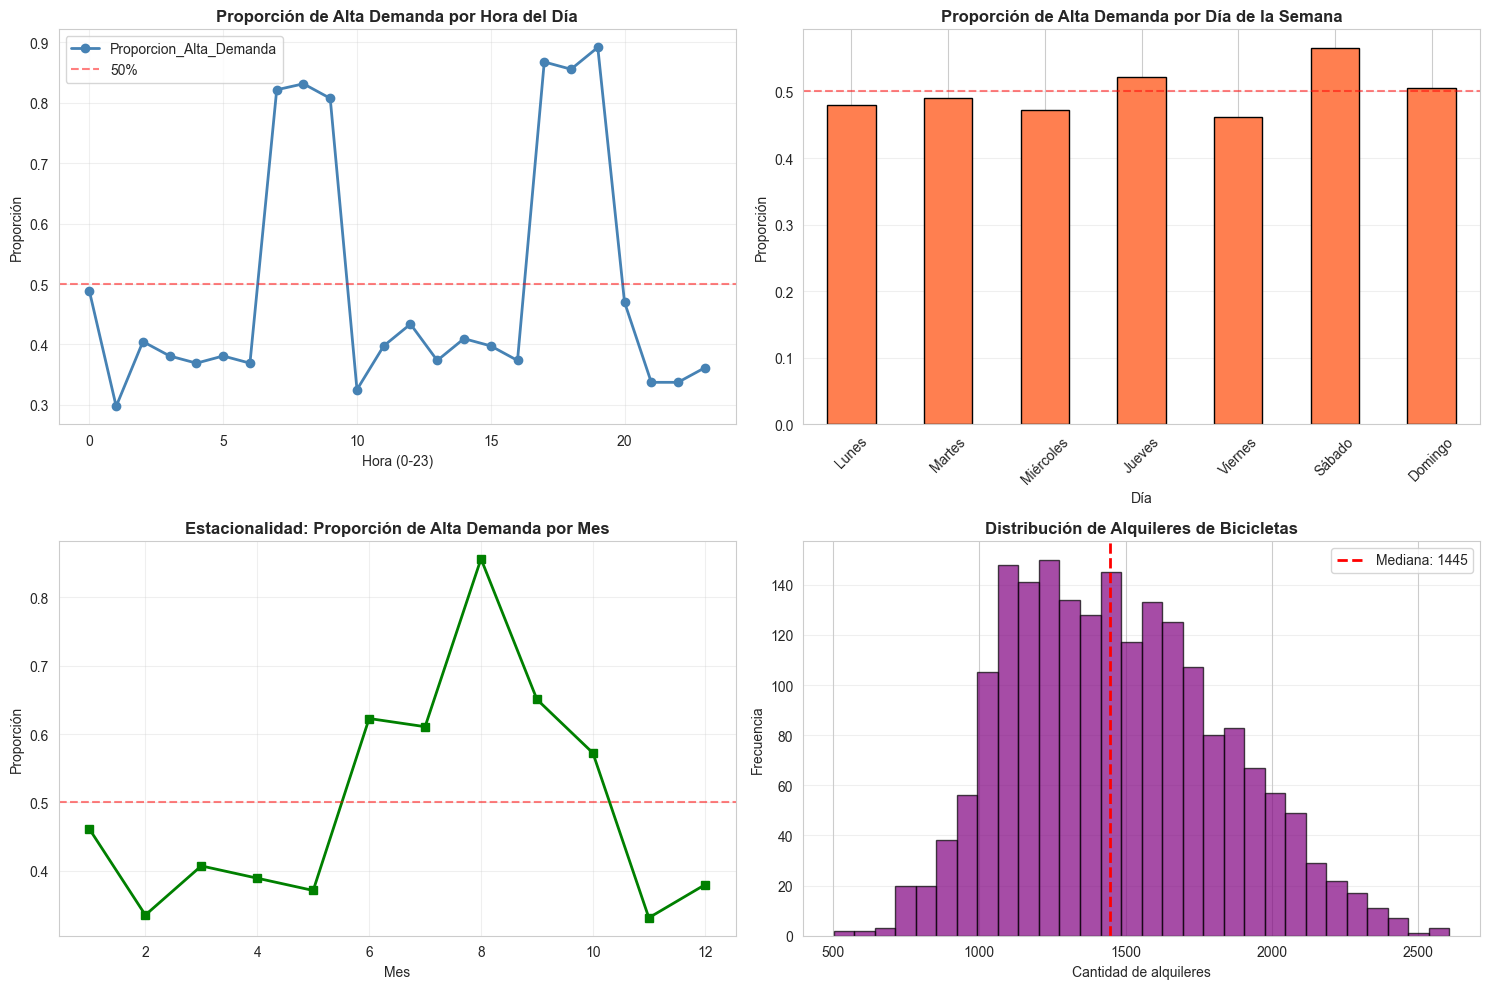


✓ OBSERVACIONES CLAVE:
  - Hora: Picos a las 7-9 AM (yendo al trabajo) y 5-7 PM (volviendo)
  - Día semana: Mayor demanda entre semana que fines de semana
  - Mes: Variación estacional (probablemente menor en invierno)


In [3]:
print("="*80)
print("PATRONES TEMPORALES EN LA DEMANDA")
print("="*80)

# Demanda por hora
demanda_por_hora = df.groupby('Hour')['High_demand'].agg(['mean', 'count'])
demanda_por_hora.columns = ['Proporcion_Alta_Demanda', 'Count']

# Demanda por día de la semana
demanda_por_dia = df.groupby('Day_of_week')['High_demand'].agg(['mean', 'count'])
demanda_por_dia.columns = ['Proporcion_Alta_Demanda', 'Count']
dias = ['Lunes', 'Martes', 'Miércoles', 'Jueves', 'Viernes', 'Sábado', 'Domingo']
demanda_por_dia.index = dias

# Demanda por mes
demanda_por_mes = df.groupby('Month')['High_demand'].agg(['mean', 'count'])
demanda_por_mes.columns = ['Proporcion_Alta_Demanda', 'Count']

# Visualizar patrones
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Demanda por hora
demanda_por_hora['Proporcion_Alta_Demanda'].plot(ax=axes[0, 0], marker='o', linewidth=2, color='steelblue')
axes[0, 0].set_title('Proporción de Alta Demanda por Hora del Día', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Hora (0-23)')
axes[0, 0].set_ylabel('Proporción')
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].axhline(y=0.5, color='red', linestyle='--', alpha=0.5, label='50%')
axes[0, 0].legend()

# Demanda por día
demanda_por_dia['Proporcion_Alta_Demanda'].plot(ax=axes[0, 1], kind='bar', color='coral', edgecolor='black')
axes[0, 1].set_title('Proporción de Alta Demanda por Día de la Semana', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Día')
axes[0, 1].set_ylabel('Proporción')
axes[0, 1].set_xticklabels(dias, rotation=45)
axes[0, 1].grid(True, alpha=0.3, axis='y')
axes[0, 1].axhline(y=0.5, color='red', linestyle='--', alpha=0.5)

# Demanda por mes
demanda_por_mes['Proporcion_Alta_Demanda'].plot(ax=axes[1, 0], marker='s', linewidth=2, color='green')
axes[1, 0].set_title('Estacionalidad: Proporción de Alta Demanda por Mes', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Mes')
axes[1, 0].set_ylabel('Proporción')
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].axhline(y=0.5, color='red', linestyle='--', alpha=0.5)

# Distribución de alquileres
axes[1, 1].hist(df['Bike_rentals'], bins=30, color='purple', alpha=0.7, edgecolor='black')
axes[1, 1].axvline(df['Bike_rentals'].median(), color='red', linestyle='--', linewidth=2, label=f'Mediana: {df["Bike_rentals"].median():.0f}')
axes[1, 1].set_title('Distribución de Alquileres de Bicicletas', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Cantidad de alquileres')
axes[1, 1].set_ylabel('Frecuencia')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("\n✓ OBSERVACIONES CLAVE:")
print("  - Hora: Picos a las 7-9 AM (yendo al trabajo) y 5-7 PM (volviendo)")
print("  - Día semana: Mayor demanda entre semana que fines de semana")
print("  - Mes: Variación estacional (probablemente menor en invierno)")

## 3. Análisis de Correlación


ANÁLISIS DE CORRELACIÓN: CLIMA vs DEMANDA


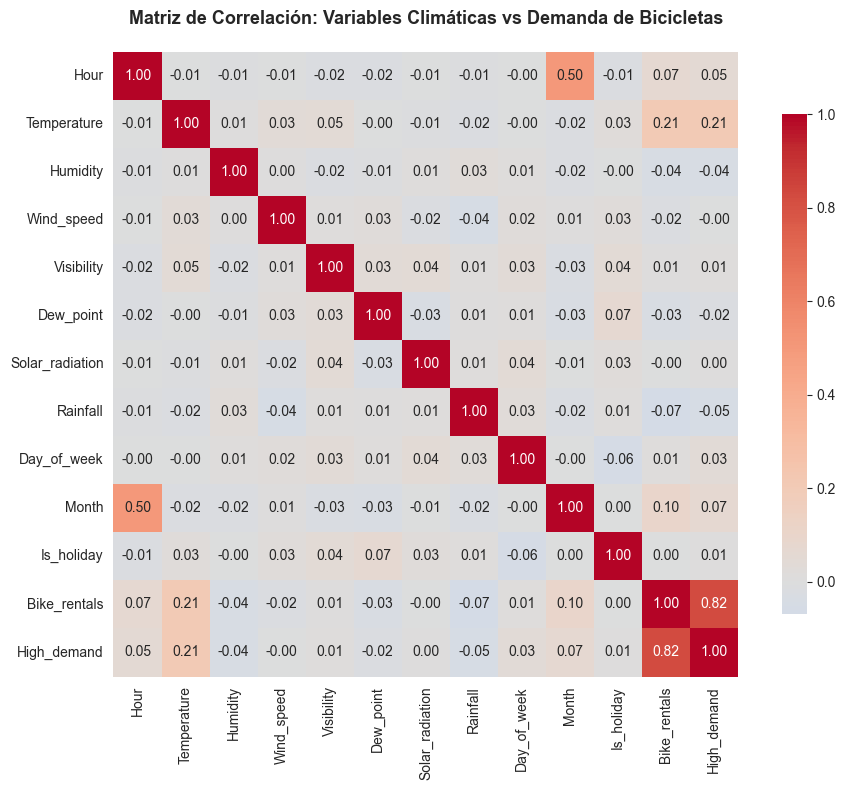


Correlación de cada variable con ALTA DEMANDA:

High_demand              : +1.0000
Bike_rentals             : +0.8213
Temperature              : +0.2080
Month                    : +0.0722
Hour                     : +0.0533
Day_of_week              : +0.0313
Visibility               : +0.0148
Is_holiday               : +0.0072
Solar_radiation          : +0.0047
Wind_speed               : -0.0043
Dew_point                : -0.0222
Humidity                 : -0.0360
Rainfall                 : -0.0507

✓ INTERPRETACIÓN:
  • Correlación positiva fuerte:  Mayor variable → Mayor demanda
  • Correlación negativa fuerte: Mayor variable → Menor demanda


In [9]:
print("\n" + "="*80)
print("ANÁLISIS DE CORRELACIÓN: CLIMA vs DEMANDA")
print("="*80)

# Variables numéricas
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

# Matriz de correlación
fig, ax = plt.subplots(figsize=(10, 8))
correlation_matrix = df[numeric_cols].corr()
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, ax=ax, cbar_kws={"shrink": 0.8})
ax.set_title('Matriz de Correlación: Variables Climáticas vs Demanda de Bicicletas',
             fontsize=13, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

# Correlaciones con la variable objetivo
print("\nCorrelación de cada variable con ALTA DEMANDA:\n")
corr_with_target = df[numeric_cols].corrwith(df['High_demand']).sort_values(ascending=False)
for feat, corr in corr_with_target.items():
    print(f"{feat:25s}: {corr:+.4f}")

print("\n✓ INTERPRETACIÓN:")
print("  • Correlación positiva fuerte:  Mayor variable → Mayor demanda")
print("  • Correlación negativa fuerte: Mayor variable → Menor demanda")

## 4. Preparación de datos y entrenamiento

In [5]:
# Seleccionar features
features = ['Hour', 'Temperature', 'Humidity', 'Wind_speed', 'Visibility', 
            'Dew_point', 'Solar_radiation', 'Rainfall', 'Day_of_week', 'Month', 'Is_holiday']

X = df[features]
y = df['High_demand']

# Dividir datos
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Conjunto de entrenamiento: {X_train.shape[0]} muestras")
print(f"Conjunto de prueba: {X_test.shape[0]} muestras")
print(f"\nFeatures usados: {len(features)}")
print(f"\n✓ Datos preparados para modelado")

Conjunto de entrenamiento: 1600 muestras
Conjunto de prueba: 400 muestras

Features usados: 11

✓ Datos preparados para modelado


## 5. Árbol de Decisión y Feature Importance


ÁRBOL DE DECISIÓN - ESTRUCTURA INTERNA


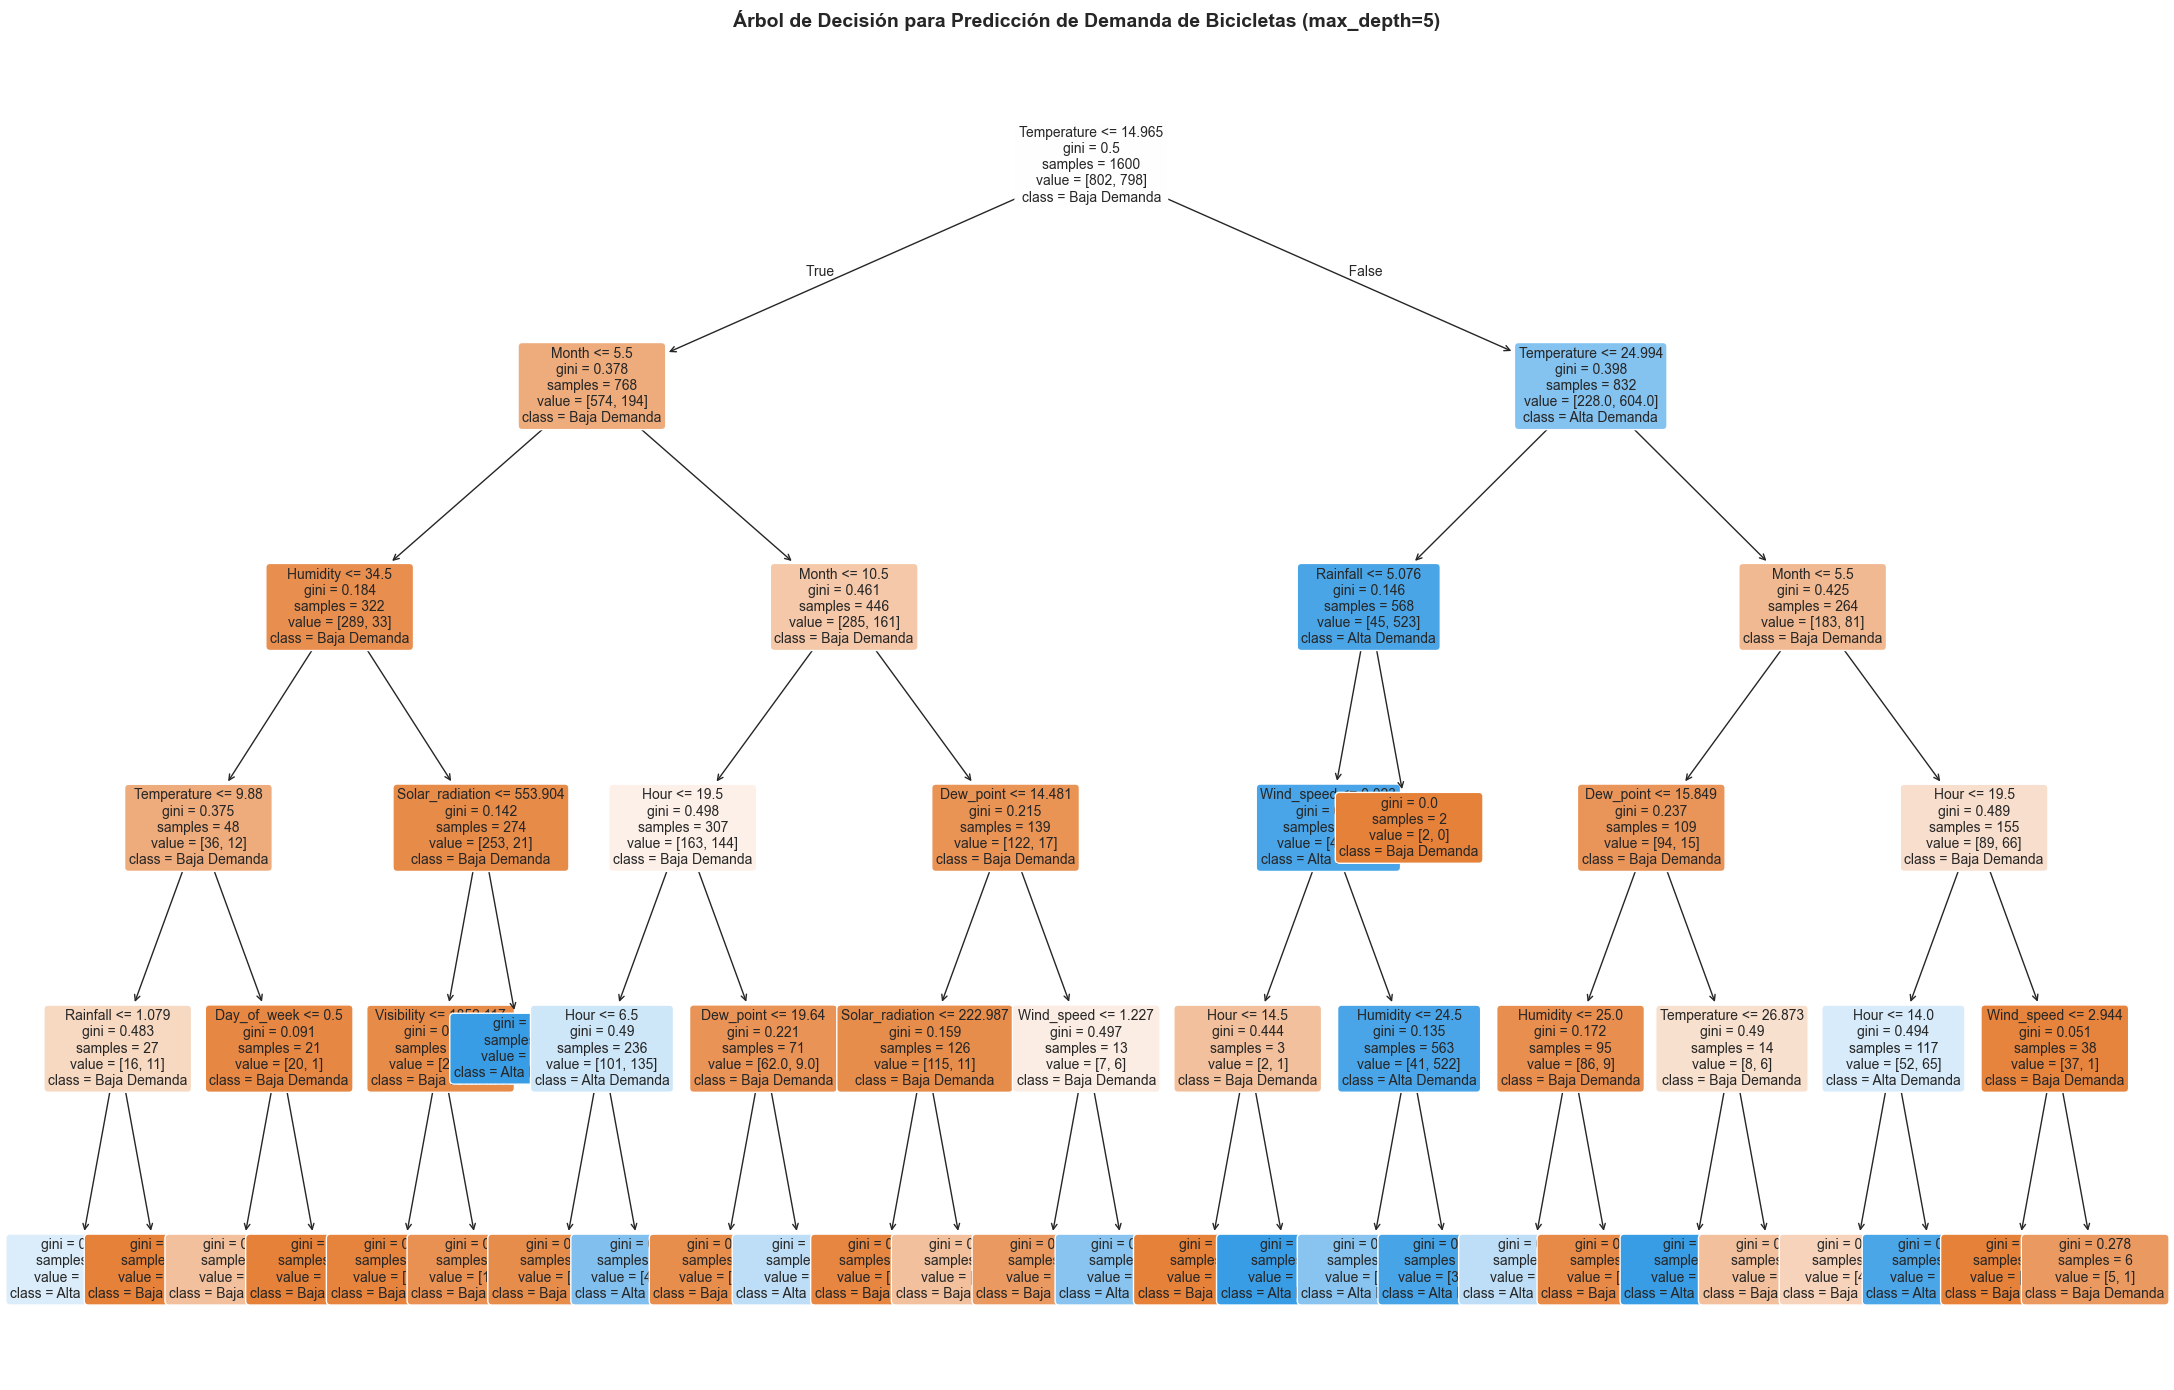


✓ Leyenda: Verde=Baja Demanda, Naranja=Alta Demanda
  Los números en cada nodo indican la decisión y distribución de clases


In [10]:
# Entrenar árbol de decisión
dt_model = DecisionTreeClassifier(max_depth=5, random_state=42)
dt_model.fit(X_train, y_train)
y_pred_dt = dt_model.predict(X_test)

print("\n" + "="*80)
print("ÁRBOL DE DECISIÓN - ESTRUCTURA INTERNA")
print("="*80)

# Visualizar árbol
fig, ax = plt.subplots(figsize=(22, 14))
plot_tree(dt_model, 
          feature_names=features,
          class_names=["Baja Demanda", "Alta Demanda"],
          filled=True,
          rounded=True,
          fontsize=10,
          ax=ax)
ax.set_title("Árbol de Decisión para Predicción de Demanda de Bicicletas (max_depth=5)", 
             fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

print("\n✓ Leyenda: Verde=Baja Demanda, Naranja=Alta Demanda")
print("  Los números en cada nodo indican la decisión y distribución de clases")


IMPORTANCIA DE CARACTERÍSTICAS EN EL MODELO

Importancia relativa:

Temperature         : 0.6378 ███████████████████████████████████████████████████████████████
Hour                : 0.1796 █████████████████
Month               : 0.1171 ███████████
Dew_point           : 0.0168 █
Humidity            : 0.0142 █
Rainfall            : 0.0131 █
Solar_radiation     : 0.0095 
Wind_speed          : 0.0086 
Visibility          : 0.0020 
Day_of_week         : 0.0011 
Is_holiday          : 0.0000 


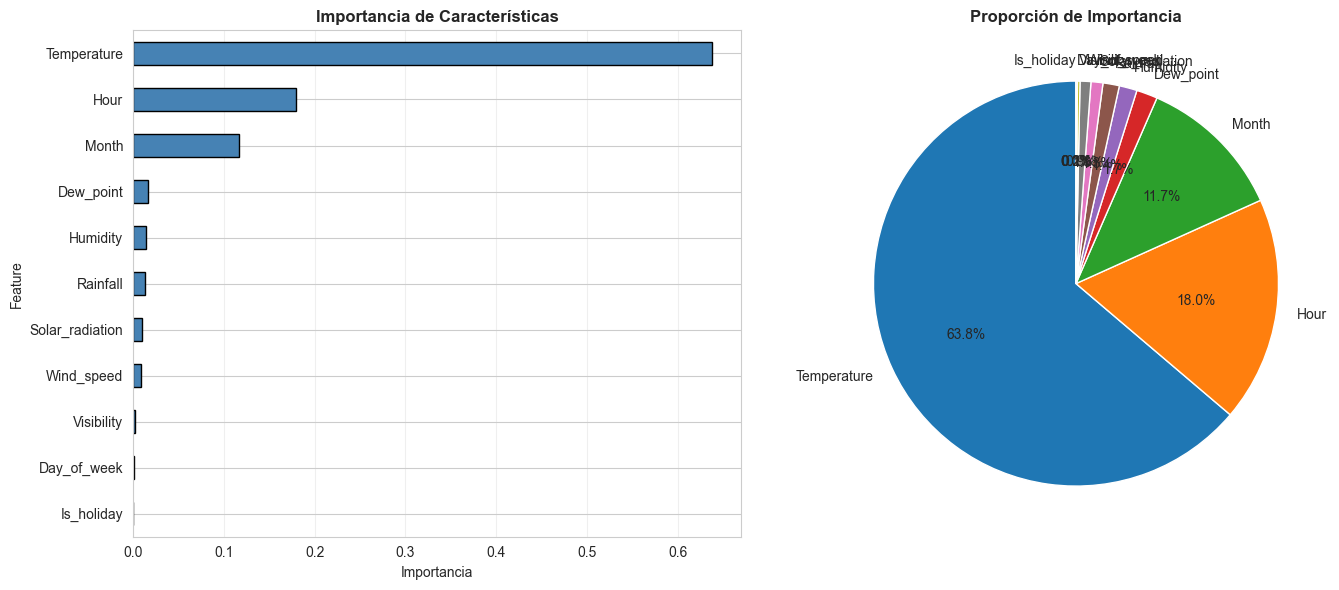


✓ CONCLUSIÓN:
  1. Temperature: 63.8%
  2. Hour: 18.0%
  3. Month: 11.7%


In [7]:
# Importancia de características
print("\n" + "="*80)
print("IMPORTANCIA DE CARACTERÍSTICAS EN EL MODELO")
print("="*80)

importances = dt_model.feature_importances_
feature_importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': importances
}).sort_values('Importance', ascending=False)

print("\nImportancia relativa:\n")
for idx, row in feature_importance_df.iterrows():
    bar = '█' * int(row['Importance'] * 100)
    print(f"{row['Feature']:20s}: {row['Importance']:6.4f} {bar}")

# Visualizar
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

feature_importance_df.sort_values('Importance').plot(
    x='Feature', y='Importance', kind='barh', ax=axes[0], 
    color='steelblue', edgecolor='black', legend=False
)
axes[0].set_title('Importancia de Características', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Importancia')
axes[0].grid(True, alpha=0.3, axis='x')

axes[1].pie(feature_importance_df['Importance'], 
            labels=feature_importance_df['Feature'],
            autopct='%1.1f%%',
            startangle=90)
axes[1].set_title('Proporción de Importancia', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

print("\n✓ CONCLUSIÓN:")
top_features = feature_importance_df.head(3)
for i, (idx, row) in enumerate(top_features.iterrows(), 1):
    print(f"  {i}. {row['Feature']}: {row['Importance']:.1%}")

## 6. Matriz de Confusión y Evaluación

## 7. Comparación de Algoritmos

## 8. Curva ROC Comparativa

## 9. Validación Cruzada

In [8]:
print("\n" + "="*80)
print("VALIDACIÓN CRUZADA (5-FOLD)")
print("="*80)

for name, model in [('Decision Tree', DecisionTreeClassifier(max_depth=5, random_state=42)),
                     ('Random Forest', RandomForestClassifier(n_estimators=100, random_state=42))]:
    print(f"\n{name}:")
    
    scores = cross_validate(
        model, X, y, cv=5,
        scoring=['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
    )
    
    for metric in ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']:
        key = f'test_{metric}'
        mean = scores[key].mean()
        std = scores[key].std()
        print(f"  {metric:10s}: {mean:.4f} ± {std:.4f}")


VALIDACIÓN CRUZADA (5-FOLD)

Decision Tree:
  accuracy  : 0.8405 ± 0.0153
  precision : 0.8408 ± 0.0237
  recall    : 0.8407 ± 0.0323
  f1        : 0.8401 ± 0.0164
  roc_auc   : 0.8737 ± 0.0073

Random Forest:
  accuracy  : 0.8550 ± 0.0152
  precision : 0.8549 ± 0.0191
  recall    : 0.8547 ± 0.0132
  f1        : 0.8548 ± 0.0146
  roc_auc   : 0.8937 ± 0.0070


## 10. Recomendaciones de Negocio